In [8]:
from pathlib import Path
from collections import Counter
from torchvision.datasets import CIFAR10

In [10]:
root = Path("./data")  
output_root = Path("./two_class_cifar")  
output_root.mkdir(parents=True, exist_ok=True)

In [9]:
dataset = CIFAR10(root="./data", train=True, download=True)

100%|██████████| 170M/170M [00:22<00:00, 7.46MB/s] 
/home/amyliu/Desktop/GR/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [11]:
from collections import defaultdict
import matplotlib.pyplot as plt

# 2. 选择两个类别
selected_classes = ["cat", "dog"]
class_to_idx = {name: i for i, name in enumerate(dataset.classes)}
selected_indices = [class_to_idx[c] for c in selected_classes]

print("Selected labels:", selected_classes)
print("Label indices:", selected_indices)

# 3. 收集每类20张
max_per_class = 20
data_per_class = defaultdict(list)

for img, label in dataset:
    if label in selected_indices:
        class_name = dataset.classes[label]
        
        if len(data_per_class[class_name]) < max_per_class:
            data_per_class[class_name].append((img, label))
    
    # 如果都收够了就提前停止（提高效率）
    if all(len(data_per_class[c]) >= max_per_class for c in selected_classes):
        break

# 4. 检查结果
for cls in selected_classes:
    print(f"{cls}: {len(data_per_class[cls])} images")

Selected labels: ['cat', 'dog']
Label indices: [3, 5]
cat: 20 images
dog: 20 images


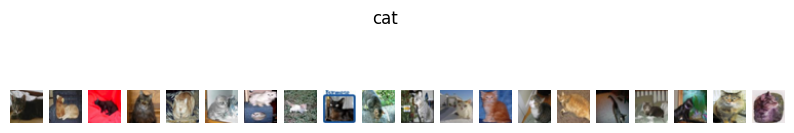

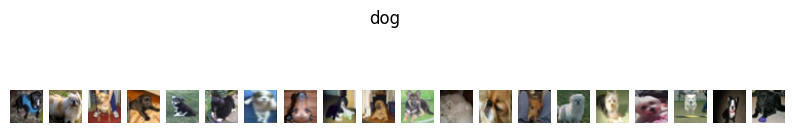

In [12]:
def show_images(data, class_name):
    plt.figure(figsize=(10, 2))
    for i, (img, _) in enumerate(data[class_name]):
        plt.subplot(1, len(data[class_name]), i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(class_name)
    plt.show()

show_images(data_per_class, "cat")
show_images(data_per_class, "dog")

In [13]:
all_images = []
all_labels = []

for cls in selected_classes:
    for img, label in data_per_class[cls]:
        all_images.append(img)
        all_labels.append(cls)

In [14]:
save_root = Path("./two_class_cifar")
save_root.mkdir(exist_ok=True)

for cls in data_per_class:
    class_dir = save_root / cls
    class_dir.mkdir(exist_ok=True)
    
    for i, (img, _) in enumerate(data_per_class[cls]):
        img.save(class_dir / f"{cls}_{i:03d}.png")

print("Saved successfully!")

Saved successfully!
